In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

In [2]:
df = pd.read_csv('soccer_match_dataset_1000_balanced.csv')
df.head(5)

,match_id,home_team,away_team,home_form_5g,away_form_5g,home_xg,away_xg,home_xga,away_xga,home_xt,...,travel_distance_away_km,h2h_home_win_ratio,missing_key_players_home,missing_key_players_away,referee_card_rate,weather_condition,kickoff_time_uk,home_goals,away_goals,result
0,M0001,Brentford,Watford,1.95,0.62,1.73,0.88,1.46,2.20,0.53,...,554,0.36,1,3,3.2,Windy,19:45,2,0,2
1,M0002,Sheffield Utd,Crystal Palace,1.28,2.05,1.28,1.62,1.94,1.73,0.46,...,401,0.40,0,2,2.2,Rainy,16:30,1,1,1
2,M0003,Sheffield Utd,Fulham,0.77,2.26,1.00,1.18,2.08,1.29,0.23,...,282,0.61,3,4,2.6,Windy,12:30,0,2,0
3,M0004,Stoke City,Southampton,1.33,1.21,1.71,0.66,1.74,2.06,0.53,...,427,0.60,1,3,2.4,Foggy,12:30,2,1,2
4,M0005,Luton Town,West Ham,2.27,1.63,1.36,1.10,1.07,1.69,0.41,...,599,0.42,4,3,3.0,Rainy,15:00,3,2,2


In [3]:
df.shape

(1000, 32)

In [4]:
df['result'].unique()

array([2, 1, 0])

In [5]:
df['weather_condition'].unique()

<StringArray>
['Windy', 'Rainy', 'Foggy', 'Clear', 'Overcast']
Length: 5, dtype: str

In [6]:
df = pd.get_dummies (df, columns=['weather_condition', 'match_importance_home', 'match_importance_away'], drop_first=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   match_id                      1000 non-null   str    
 1   home_team                     1000 non-null   str    
 2   away_team                     1000 non-null   str    
 3   home_form_5g                  1000 non-null   float64
 4   away_form_5g                  1000 non-null   float64
 5   home_xg                       1000 non-null   float64
 6   away_xg                       1000 non-null   float64
 7   home_xga                      1000 non-null   float64
 8   away_xga                      1000 non-null   float64
 9   home_xt                       1000 non-null   float64
 10  away_xt                       1000 non-null   float64
 11  home_sot                      1000 non-null   int64  
 12  away_sot                      1000 non-null   int64  
 13  home_attack_str

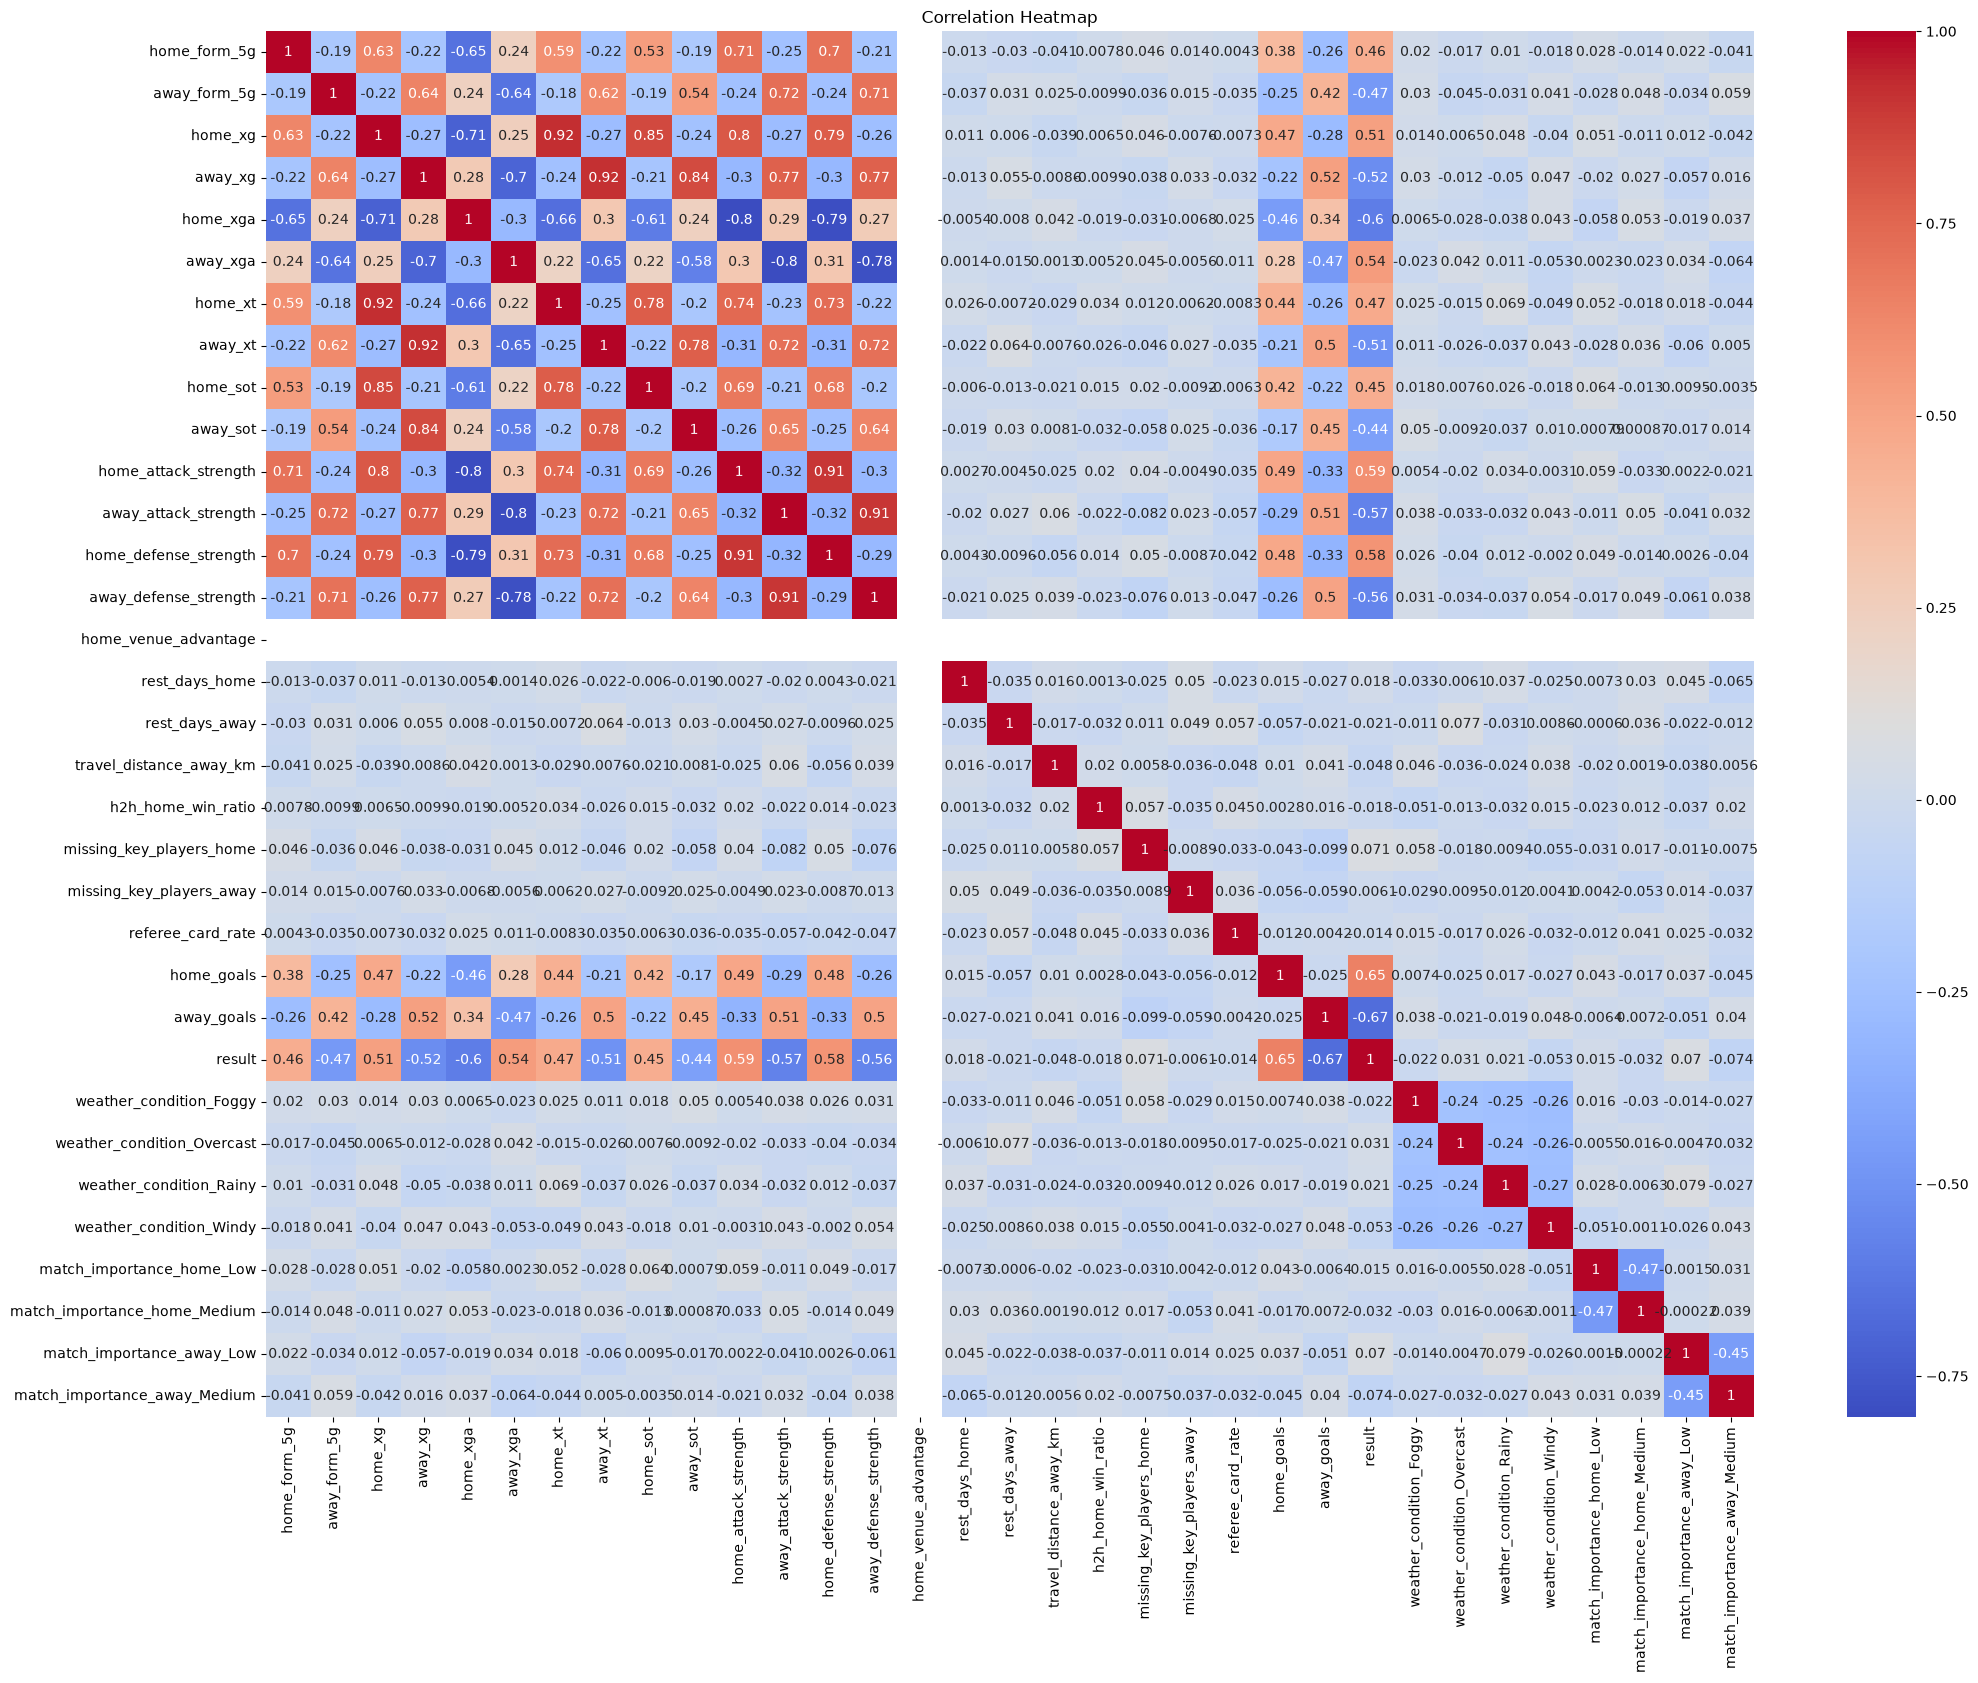

In [8]:
#Correlation heatmap
plt.figure(figsize=(24,18))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
#plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [9]:
df.columns

Index(['match_id', 'home_team', 'away_team', 'home_form_5g', 'away_form_5g',
       'home_xg', 'away_xg', 'home_xga', 'away_xga', 'home_xt', 'away_xt',
       'home_sot', 'away_sot', 'home_attack_strength', 'away_attack_strength',
       'home_defense_strength', 'away_defense_strength',
       'home_venue_advantage', 'rest_days_home', 'rest_days_away',
       'travel_distance_away_km', 'h2h_home_win_ratio',
       'missing_key_players_home', 'missing_key_players_away',
       'referee_card_rate', 'kickoff_time_uk', 'home_goals', 'away_goals',
       'result', 'weather_condition_Foggy', 'weather_condition_Overcast',
       'weather_condition_Rainy', 'weather_condition_Windy',
       'match_importance_home_Low', 'match_importance_home_Medium',
       'match_importance_away_Low', 'match_importance_away_Medium'],
      dtype='str')

In [10]:
features = ['home_form_5g', 'away_form_5g','home_xg', 'away_xg', 'home_xga', 'away_xga', 
            'home_xt', 'away_xt', 'home_sot', 'away_sot', 'home_attack_strength', 'away_attack_strength', 
            'home_defense_strength', 'away_defense_strength', 'rest_days_home', 'rest_days_away', 'travel_distance_away_km', 'h2h_home_win_ratio', 
            'missing_key_players_home', 'missing_key_players_away', 'referee_card_rate']
x = df[features].values
y = df['result'].values

In [11]:
x.shape

(1000, 21)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.2, random_state=24, stratify=y)

In [13]:
x_test.shape

(800, 21)

In [21]:
Soccer_Prediction = RandomForestClassifier(n_estimators=100, criterion='gini', class_weight='balanced', random_state=24)
Soccer_Prediction.fit(x_train, y_train)
y_pred = Soccer_Prediction.predict(x_test)

In [22]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.81      0.73       267
           1       0.55      0.44      0.49       267
           2       0.73      0.71      0.72       266

    accuracy                           0.65       800
   macro avg       0.65      0.65      0.64       800
weighted avg       0.65      0.65      0.64       800

0.6525


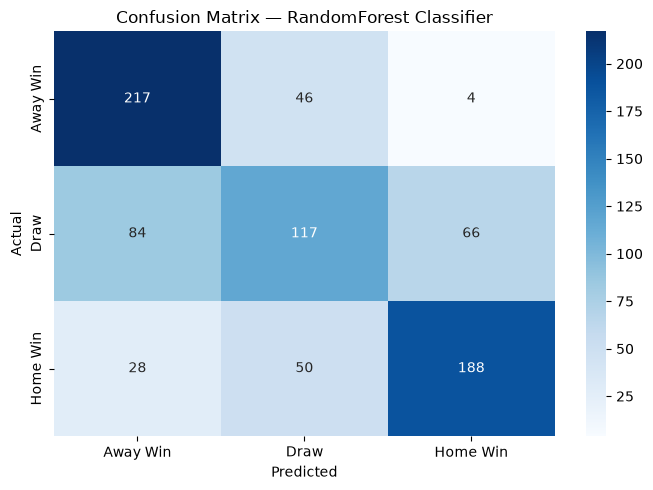


Confusion matrix saved → confusion_matrix.png


In [23]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Away Win", "Draw", "Home Win"]
 
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels
)
plt.title("Confusion Matrix — RandomForest Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
#plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("\nConfusion matrix saved → confusion_matrix.png")

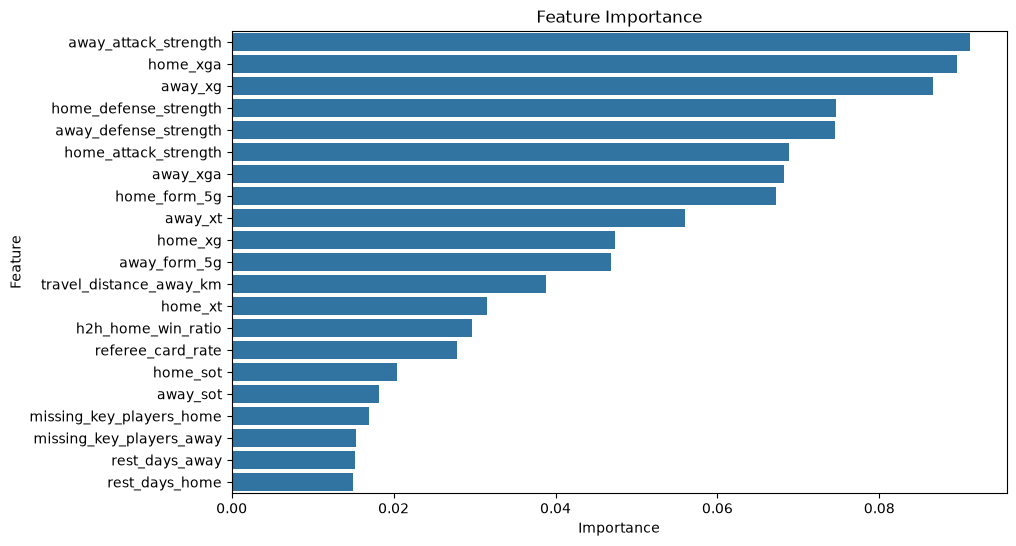

All Feature Importances:
                     Feature  Importance
11      away_attack_strength    0.091170
4                   home_xga    0.089559
3                    away_xg    0.086598
12     home_defense_strength    0.074692
13     away_defense_strength    0.074469
10      home_attack_strength    0.068838
5                   away_xga    0.068259
0               home_form_5g    0.067192
7                    away_xt    0.055990
2                    home_xg    0.047297
1               away_form_5g    0.046843
16   travel_distance_away_km    0.038879
6                    home_xt    0.031574
17        h2h_home_win_ratio    0.029694
20         referee_card_rate    0.027850
8                   home_sot    0.020365
9                   away_sot    0.018236
18  missing_key_players_home    0.016960
19  missing_key_players_away    0.015316
15            rest_days_away    0.015192
14            rest_days_home    0.015028


In [24]:
#Using feature importanctance to know the most predictive features of BOE
feature_names = df[features].columns
importance_df = pd.DataFrame({'Feature': feature_names,'Importance': Soccer_Prediction.feature_importances_})
importance_df = (importance_df.sort_values('Importance', ascending=False))
#visualizing the top 10 most important features using a bar plot
top30 = importance_df.head(30)
plt.figure(figsize=(10,6))
sns.barplot(data=top30, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.savefig("feature_importances.png", dpi=150, bbox_inches='tight')
plt.show()
print("All Feature Importances:")
print(importance_df)

In [18]:
# Count frequencies of each class directly from the NumPy array
classes, counts = np.unique(y_train, return_counts=True)
total = len(y_train)

# Weight = total / (num_classes * count_per_class)
class_weights = {cls: total / (3 * count) for cls, count in zip(classes, counts)}

In [26]:
#Saving the failure detection model
joblib.dump(Soccer_Prediction, 'Soccer_Prediction.pkl')
print('Yuur model has been saved, successfully.')

Yuur model has been saved, successfully.


In [29]:
Soccer_Prediction = joblib.load('Soccer_Prediction.pkl')

In [30]:
new_match = pd.DataFrame([{
    "home_form_5g": 0.67,
    "away_form_5g": 0.73,
    "home_xg": 1.73,
    "away_xg": 2.03,
    "home_xga": 1.3,
    "away_xga": 1.0,
    "home_xt": 1.93,
    "away_xt": 0.96,
    "home_sot": 6.7,
    "away_sot": 5.3,
    "home_attack_strength": 1.13,
    "away_attack_strength": 0.68,
    "home_defense_strength": 1.05,
    "away_defense_strength": 1.4,
    "rest_days_home": 3,
    "rest_days_away": 4,
    "travel_distance_away_km": 0,
    "h2h_home_win_ratio": 0,
    "missing_key_players_home": 1, 
    "missing_key_players_away": 2,
    "'referee_card_rate": 4.74,
}])
 
probs = Soccer_Prediction.predict_proba(new_match)[0]
pred_class = Soccer_Prediction.predict(new_match)[0]
outcome_map = {0: "Away Win", 1: "Draw", 2: "Home Win"}
 
print("\n" + "="*50)
print("              NETHERLANDS VS MOROCCO")
print("="*50)
print(f"Away Win Probability : {probs[0]:.3f}")
print(f"Draw Probability     : {probs[1]:.3f}")
print(f"Home Win Probability : {probs[2]:.3f}")
print(f"Prediction    : {outcome_map[pred_class]}")
 

[06/29/26 11:54:09] WARNING  c:\Users\USER\Control\day1\.venv\Lib\site-packages\sklearn\utils\v ]8;id=16210137;file://C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=16210138;file://C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             alidation.py:2820: UserWarning: X has feature names, but                              
                             RandomForestClassifier was fitted without feature names                               
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\USER\Control\day1\.venv\Lib\site-packages\sklearn\utils\v ]8;id=16210143;file://C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=16210144;file://C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             alidation.py:2820: UserWarning: X has feature names, but                              
                             RandomForestClassifier was fitted without feature names                               
                               warnings.warn(                                                                      
                                                                                                                   


              NETHERLANDS VS MOROCCO
Away Win Probability : 0.350
Draw Probability     : 0.340
Home Win Probability : 0.310
Prediction    : Away Win
